In [8]:
# Let's import python libraries first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # visualizing data
%matplotlib inline
import seaborn as sns

In [15]:
# import csv file
df = pd.read_csv(R'Downloads/Python file project/Sales_Data (3).csv', encoding= 'unicode_escape')

In [19]:
# Check Number of rows and columns
df.shape

(11257, 13)

In [22]:
# To see the imported data
df.head()     # Show Top 5 Rows

,User_ID,Cust_name,Product_ID,Age,Age Group,Gender,State,Zone,Zipcode,Profession,Product_Category,Orders,Amount
0,1002903.0,Anvi,P00125942,27.0,26-35,Female,Maharashtra,West,NaN,Healthcare,Sports,4.0,20500.0
1,1000732.0,Shanta,P00110942,34.0,26-35,Female,Andhra Pradesh,South,NaN,Govt,Sports,2.0,25360.0
2,1001990.0,Sheetal,P00118542,16.0,0-17,Female,Uttar Pradesh,Central,NaN,Automobile,Health,4.0,29350.0
3,1001425.0,Virendra,P00237842,16.0,0-17,M,Karnataka,South,NaN,Construction,Clothing,6.0,23500.0
4,1000588.0,Vishal,P00057942,28.0,26-35,M,Gujarat,West,NaN,Food Processing,Electronics,4.0,23870.0


In [23]:
# Field details and Data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11257 entries, 0 to 11256
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11245 non-null  float64
 1   Cust_name         11245 non-null  str    
 2   Product_ID        11245 non-null  str    
 3   Age               11245 non-null  float64
 4   Age Group         11245 non-null  str    
 5   Gender            11245 non-null  str    
 6   State             11245 non-null  str    
 7   Zone              11245 non-null  str    
 8   Zipcode           0 non-null      float64
 9   Profession        11245 non-null  str    
 10  Product_Category  11245 non-null  str    
 11  Orders            11245 non-null  float64
 12  Amount            11245 non-null  float64
dtypes: float64(5), str(8)
memory usage: 1.7 MB


## Let's Start Data Cleaning

In [25]:
# Deleting blank column
df.drop(['Zipcode'],axis=1,inplace=True) 
# axis=1 for delete column, axis=0 for delete row 
# inplace=true for save perticular_column

In [26]:
# List of Columns Available
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Age', 'Age Group', 'Gender',
       'State', 'Zone', 'Profession', 'Product_Category', 'Orders', 'Amount'],
      dtype='str')

In [28]:
# Check for null values
pd.isnull(df).sum()

User_ID             12
Cust_name           12
Product_ID          12
Age                 12
Age Group           12
Gender              12
State               12
Zone                12
Profession          12
Product_Category    12
Orders              12
Amount              12
dtype: int64

In [29]:
# drop null values
df.dropna(how='all', inplace=True)
# how='any' delete some rows
# how='all' delete for entire row

In [30]:
df.shape

(11245, 12)

In [32]:
# replace value of Gender Column
df['Gender'] = df['Gender'].replace('M', 'Male')

In [ ]:
# View only Male Gender Data
df[df['Gender'] == 'Male']

## --> Now Let's Learn EDA - Exploratory Data Analysis

In [ ]:
# describe() method returns description of the data in the DataFrame(i.e. count, mean, std, etc)
df.describe()

In [35]:
# Use Describe() for Specific Columns
# Create a List like show output
df[['Age', 'Orders', 'Amount']].describe()     

,Age,Orders,Amount
count,11245.000000,11245.000000,11245.000000
mean,35.415651,3.500311,9461.934237
std,12.756369,1.713706,5234.426634
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,4.000000,8109.000000
75%,43.000000,5.000000,12683.000000
max,92.000000,6.000000,29350.000000


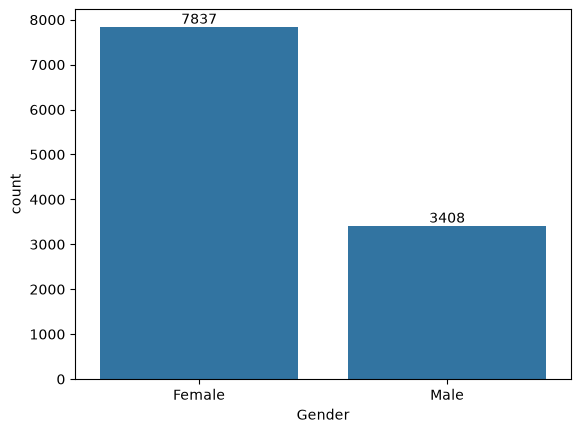

In [38]:
# Bar_Chart
ax=sns.countplot(x='Gender', data = df)
for bars in ax.containers:
    ax.bar_label(bars)    # add_label for formating 
plt.show()

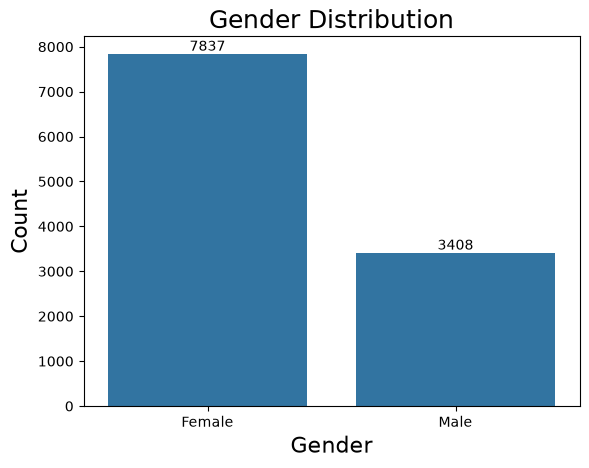

In [42]:
#1.  Total Transaction count by Gender Wise in Bar Chart
ax = sns.countplot(x = 'Gender', data = df)           # for formating

# set Title and Label with Font Size
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_title('Gender Distribution', fontsize=18)   # Chart Title
    ax.set_xlabel('Gender', fontsize=16)               # x-Axis Label
    ax.set_ylabel('Count', fontsize=16)                # y-Axis Label
    ax.tick_params(axis='both', labelsize=10)          # Axis Parameters
    plt.show()

###  #2. Gender wise distribution in Pie Chart

In [44]:
# Total Transactions Count by Gender in Pie Chart
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
Female    7837
Male      3408
Name: count, dtype: int64


#### Total Transctions Count by Gender wise in Pie Chart

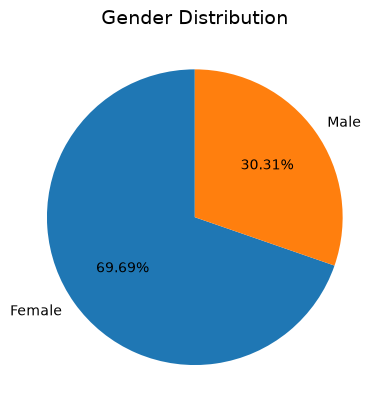

In [45]:
# Total Transactions Count by Gender wise in Pie Chart
gender_counts = df['Gender'].value_counts()

plt.pie(
    gender_counts,                 # Data (counts)
    labels=gender_counts.index,    # Labels(e.g., Male, Female)
    autopct='%1.2f%%',             # Show percentage (2 decimal place)
    startangle=90,                 # Rotate for better orientation
)
# Add a title
plt.title('Gender Distribution', fontsize=14)
plt.show()

In [49]:
df.groupby('Gender')['Amount'].sum()

Gender
Female    74461610.49
Male      31937840.00
Name: Amount, dtype: float64

In [48]:
df.groupby('Gender', as_index=False)['Amount'].sum()

,Gender,Amount
0,Female,74461610.49
1,Male,31937840.00


In [47]:
df.groupby('Product_Category')['Orders'].sum()

Product_Category
Beauty         8188.0
Clothing       7597.0
Electronics    7812.0
Health         7711.0
Sports         8053.0
Name: Orders, dtype: float64

In [51]:
Gen_Wise_Sales = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
print(Gen_Wise_Sales)

   Gender       Amount
0  Female  74461610.49
1    Male  31937840.00


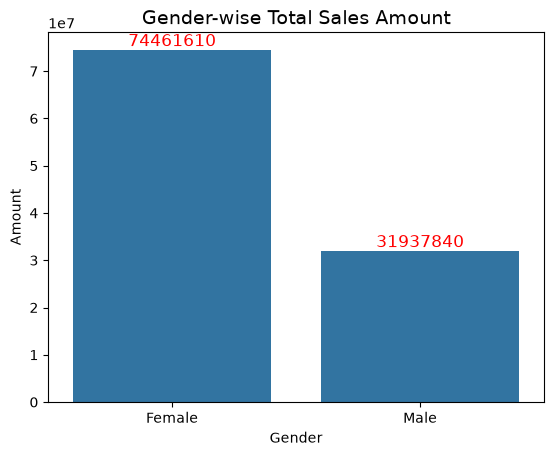

In [55]:
# Gender wise Total Sales Amount

# step1: Group data by Gender and sum the Amount
Gen_Wise_Sales = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# step2: Create the bar plot
ax = sns.barplot(x='Gender', y='Amount', data=Gen_Wise_Sales)

# step3: Add data labels on top of bar
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.0f', fontsize=12, color='red')      # Show counts as whole number

# step4: Add titles
plt.title('Gender-wise Total Sales Amount', fontsize=14)b
plt.show()

## --> Age group wise total Transactions

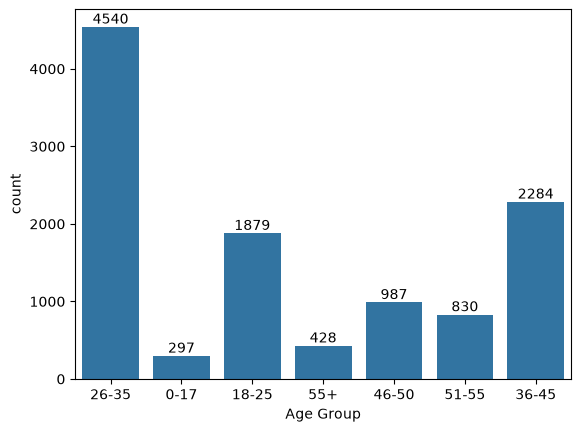

In [57]:
# Age Groupwise Transactions Count in Bar Chart
ax = sns.countplot(data = df, x = 'Age Group')

for bars in ax.containers:            # Show Data Labels
    ax.bar_label(bars)
    plt.show()

Age Group
26-35    4540
36-45    2284
18-25    1879
46-50     987
51-55     830
55+       428
0-17      297
Name: count, dtype: int64


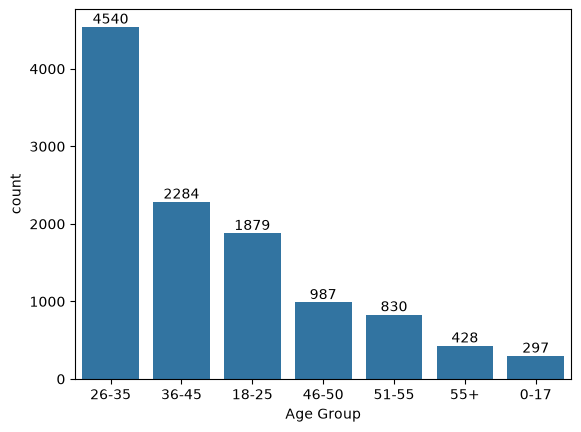

In [59]:
# Step 1: Age group wise transaction count(SORTING)

age_group_counts=df['Age Group'].value_counts().sort_values(ascending=False)      # always capital (F)=descending
print(age_group_counts)                                                           # always capital (T)=ascending

# Step 2: Use Ordered categories for sorting in countplot
sns_order=age_group_counts.index

# Age Groupwise Transactions Count in Bar Chart
ax = sns.countplot(data = df, x = 'Age Group', order=sns_order)

for bars in ax.containers:            # Show Data Labels
    ax.bar_label(bars)
    plt.show()


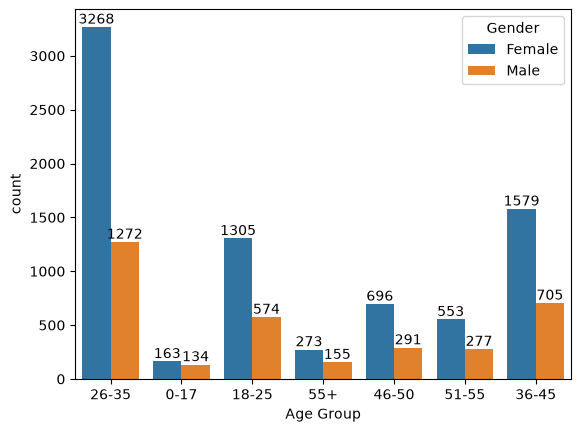

In [60]:
# Age group and Gender wise Transactions distribution

ax = sns.countplot(data = df, x='Age Group', hue='Gender')        # hue allow as a legend of male/female

for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

#### From above graphs we can see that most of the buyers are of age group between 26-35 year 

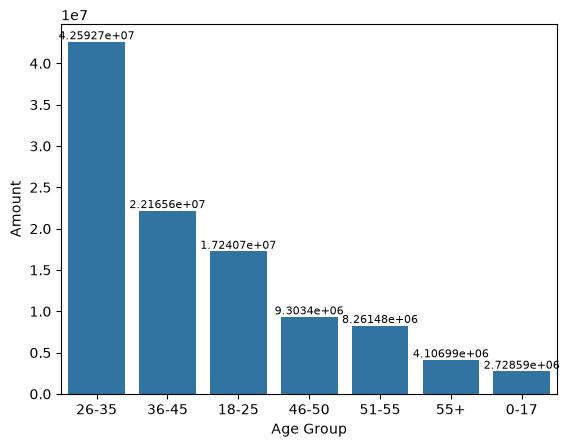

In [72]:
# Age Group wise Total Amount
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

ax=sns.barplot(x ='Age Group', y = 'Amount', data = sales_age)

for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)
    
plt.show()

### --> State wise analysis

In [75]:
# Order wise Top 5 state
order_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(5)
print(order_state)

             State  Orders
14   Uttar Pradesh  6669.0
10     Maharashtra  5328.0
7        Karnataka  4506.0
2            Delhi  3893.0
9   Madhya Pradesh  3217.0


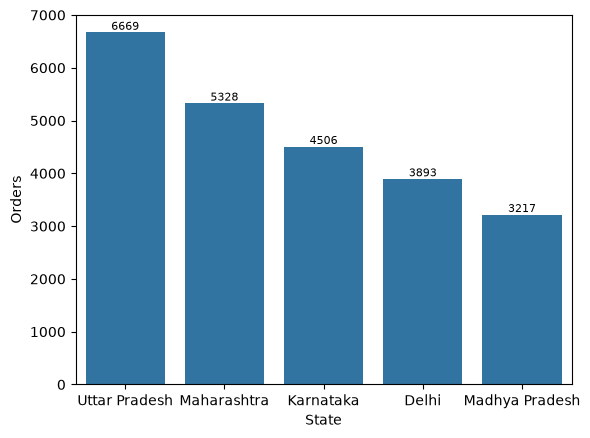

In [78]:
# Order wise Top 5 state
order_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(5)

# sns.set(rc={'figure.figsize':(15,5)})
ax = sns.barplot(data = order_state, x = 'State', y = 'Orders')
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)
plt.show()

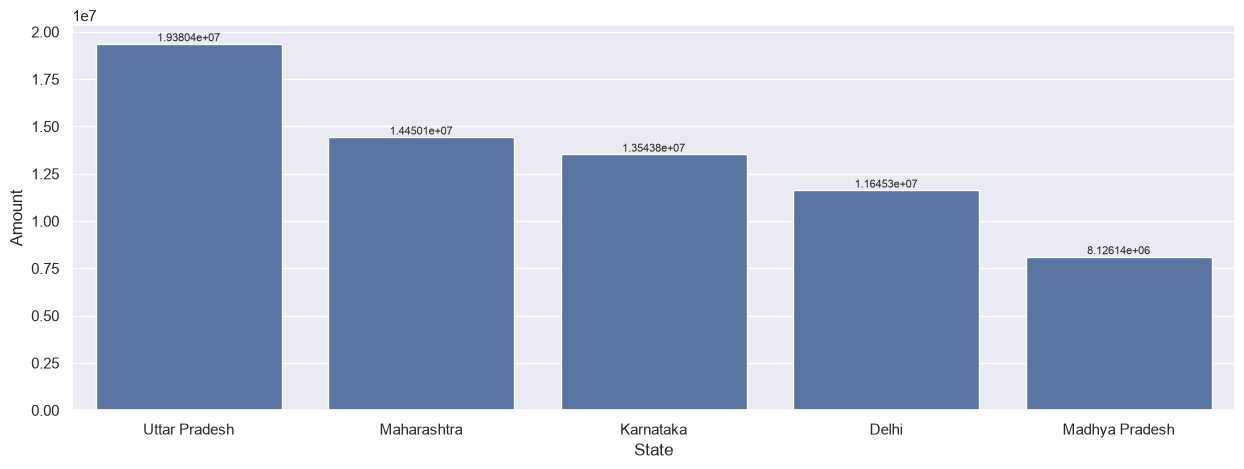

In [83]:
# Amount Wise top 5 state

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(5)

sns.set(rc={'figure.figsize':(15,5)})
ax = sns.barplot(data = sales_state, x = 'State', y = 'Amount')
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)
plt.show()

##### from above graph we can see that most of the orders & total sales/amount are from Uttar_Pradesh, Maharashtra, Karnataka respectively

### --> Product_Category Analysis

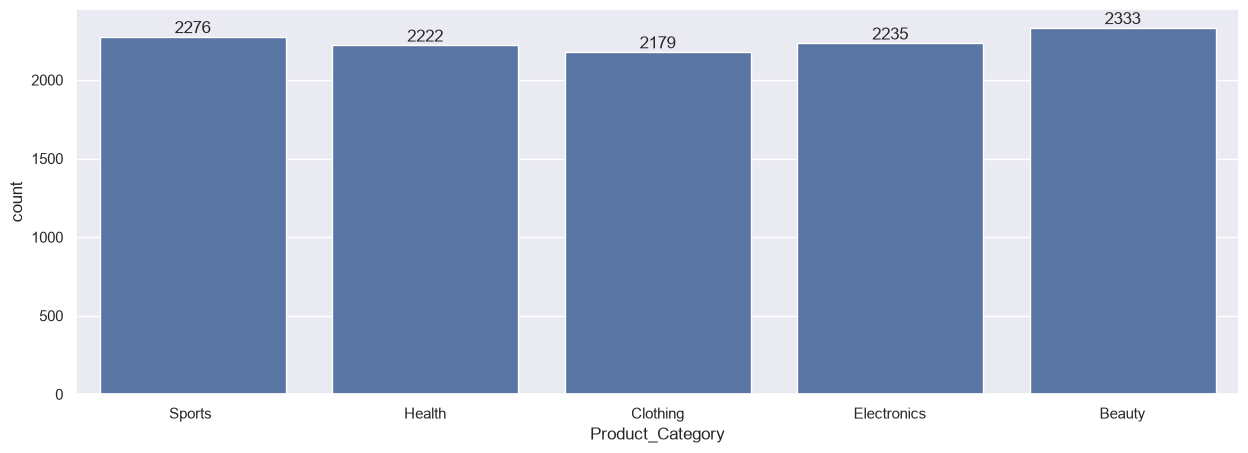

In [84]:
# Product Category Wise Transactions Count
ax = sns.countplot(data = df, x = 'Product_Category')

sns.set(rc={'figure.figsize':(7,5)})

for bars in ax.containers:
    ax.bar_label(bars)
plt.show()


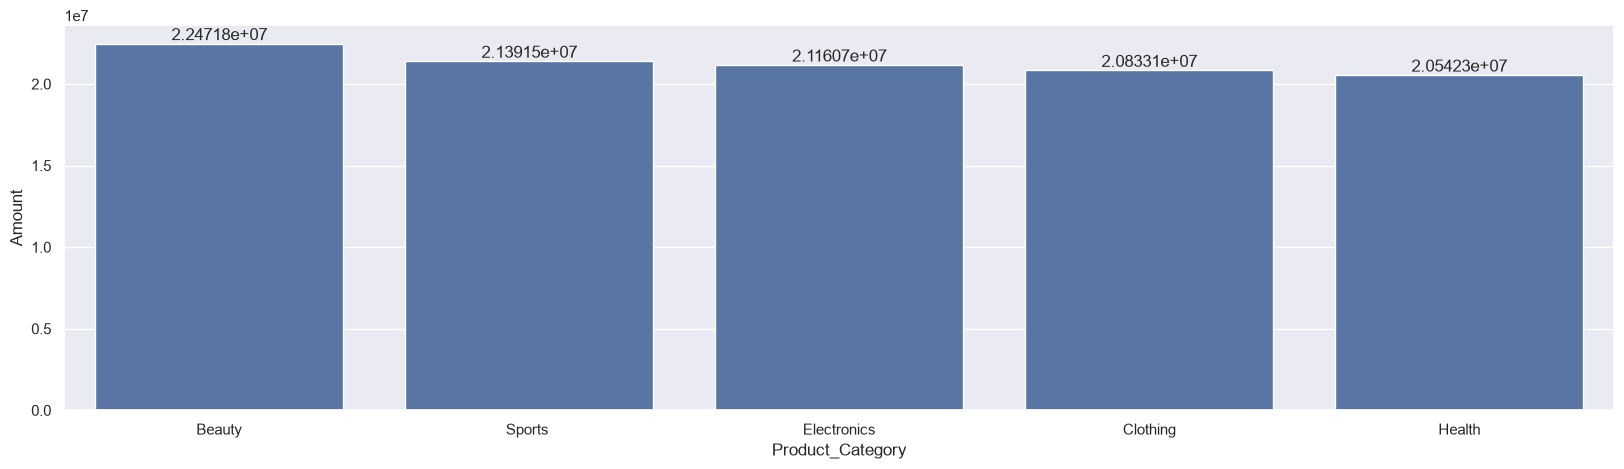

In [86]:
# Amount Wise Product Category in Bar Chart
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
ax = sns.barplot(data = sales_state, x = 'Product_Category', y = 'Amount')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

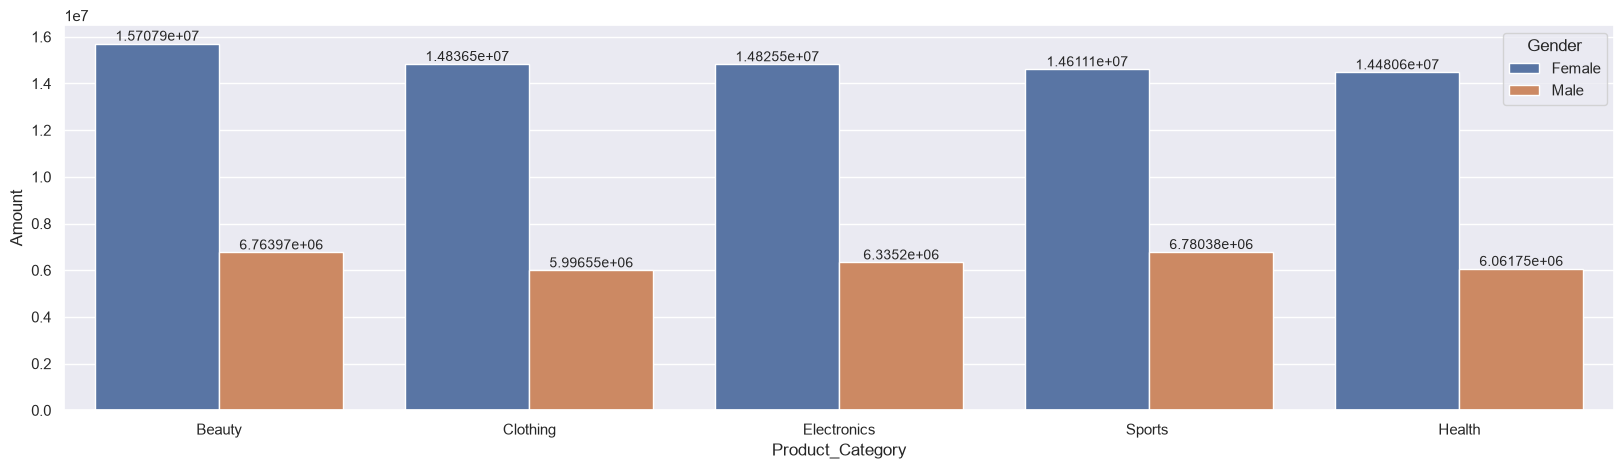

In [89]:
# Product Category and Gender Wise Transaction Count
sales_pro=df.groupby(['Product_Category', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

ax = sns.barplot(data=sales_pro, x='Product_Category', y='Amount', hue='Gender')    # hue-add to legend

for bars in ax.containers:
    ax.bar_label(bars, fontsize=10)
plt.show()

### --> Profession Wise Analysis

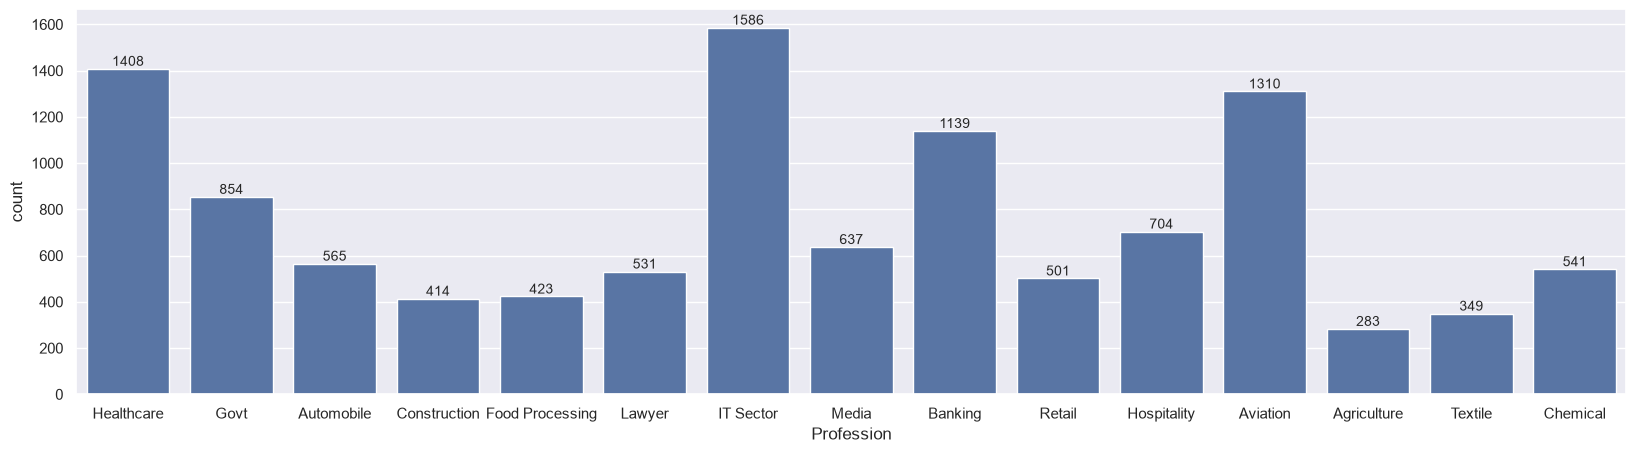

In [90]:
# Profession Wise Transactions Count
ax = sns.countplot(data = df, x = 'Profession')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=10)
    
plt.show()

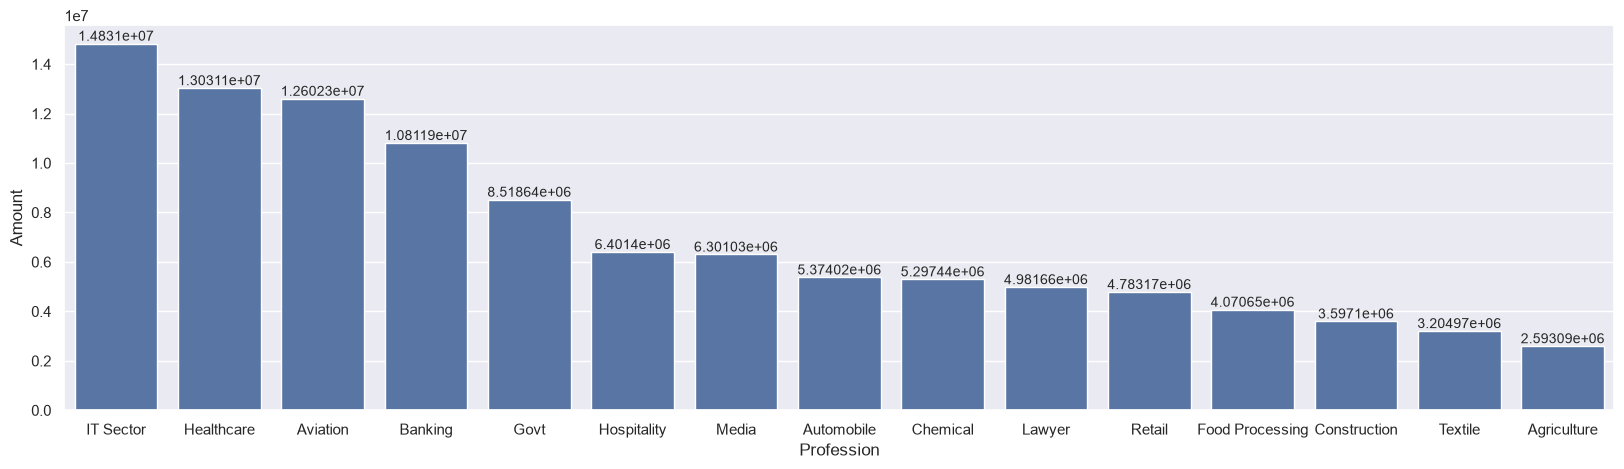

In [93]:
# Amount Wise Top Profession
sales_state = df.groupby(['Profession'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
# .head(3) also add

sns.set(rc={'figure.figsize':(20,5)})
ax = sns.barplot(data = sales_state, x = 'Profession', y = 'Amount')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=10)
    
plt.show()

##### From above graph we can see that most of the buyers are working in IT, Healthcare and Aviation sector

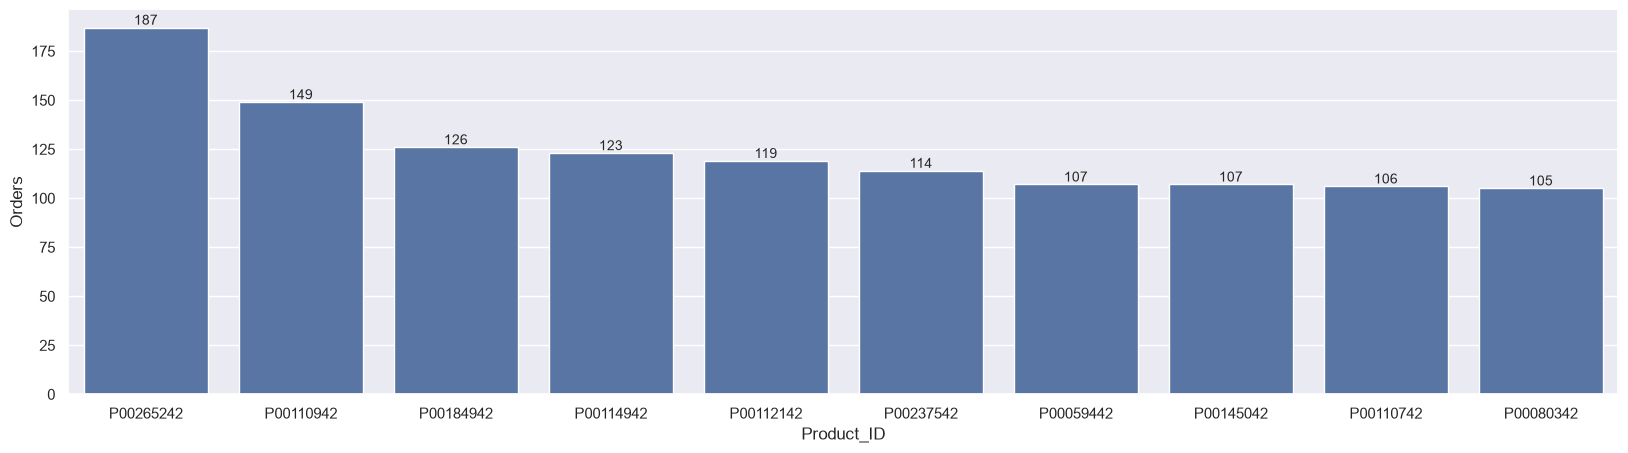

In [100]:
# Order Wise Top 10 Product

sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
ax = sns.barplot(data = sales_state, x = 'Product_ID', y = 'Orders')

for bars in ax.containers:
    ax.bar_label(bars, fontsize=10)
    
plt.show()


### Conclusion

#### Female are group 26-35 yrs from UP,Maharashtra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from beauty, Sprots and Electronics